# Project Work XAI

In [1]:
import torch

device_try = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device_try}")

Selected device: cuda


In [2]:
import os

print("=== TEST TMUX ===")
tmux_var = os.environ.get("TMUX")

if tmux_var:
    print("STATUS: Jupyter server is running in a TMUX session!")
    print(f"Tmux socket path: {tmux_var}")
else:
    print("STATUS: The Jupyter server is NOT inside Tmux (it runs in the global terminal).")

=== TEST TMUX ===
STATUS: Jupyter server is running in a TMUX session!
Tmux socket path: /tmp//tmux-1022/default,842946,2


In [3]:
import os
print(os.getpid())

1516126


In [4]:
import os
print("Il mio PID:", os.getpid())
print("Il PID del processo Padre (chi mi ha avviato):", os.getppid())

Il mio PID: 1516126
Il PID del processo Padre (chi mi ha avviato): 1488280


In [5]:
!nvidia-smi

Sat May 23 17:44:11 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 2070 ...    Off | 00000000:04:00.0 Off |                  N/A |
| 39%   31C    P8              11W / 215W |     19MiB /  8192MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [6]:
import os
import torch

print("=== 🕵️ TEST ARCHITETTURA DEFINITIVO (PYTORCH) ===")

# Verifica cosa ha ereditato dal terminale
cuda_vis = os.environ.get("CUDA_VISIBLE_DEVICES")
print(f"1. Variabile CUDA_VISIBLE_DEVICES ereditata: {cuda_vis}")

print(f"\n2. PYTORCH:")
print(f"   - Quante GPU vede all'interno del suo recinto: {torch.cuda.device_count()}")

cuda_available = torch.cuda.is_available()
if cuda_available:
    gpu_name = torch.cuda.get_device_name(0) # Usa sempre 0, perché è l'unica che vede!
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   - Modello agganciato: {gpu_name}")
    print(f"   - Total VRAM memory: {total_memory:.2f} GB")
else:
    print("   - WARNING: PyTorch sta usando la CPU.")

# Test di allocazione
device = torch.device("cuda" if cuda_available else "cpu")
x = torch.randn(1000, 1000).to(device)
print(f"\nTest tensore allocato su: {x.device}")

=== 🕵️ TEST ARCHITETTURA DEFINITIVO (PYTORCH) ===
1. Variabile CUDA_VISIBLE_DEVICES ereditata: 0

2. PYTORCH:
   - Quante GPU vede all'interno del suo recinto: 1
   - Modello agganciato: NVIDIA GeForce RTX 2080 SUPER
   - Total VRAM memory: 8.36 GB

Test tensore allocato su: cuda:0


In [7]:
device = torch.device("cuda" if cuda_available else "cpu")
print(f"Device: {device}") # now it works

Device: cuda


## Environment management

In [8]:
import os
import sys

# detecting environment
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

# setting filesystem and paths
if is_colab():
    print("Running in Google Colab detected.")
    # cloning repository
    repo_url = "https://github.com/Epot12/Lab_XAI.git"
    repo_name = "Lab_XAI"

    # cloning only if it hasn't already been done in this session
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # changing the working directory to the project directory
    os.chdir(repo_name)

    # Adding the folder to the system paths
    sys.path.append(os.getcwd())
    print(f"Working directory set to: {os.getcwd()}")

else:
    from pathlib import Path
    print("Local execution detected.")
    def project_root():
        current = Path.cwd().resolve()
        for path in [current] + list(current.parents):
            if (path / ".git").exists():
                return path
        raise RuntimeError("Project root not found")

    os.chdir(project_root())
    sys.path.append(str(project_root()))
    print(f"Working directory set to: {os.getcwd()}")

Local execution detected.
Working directory set to: /home/emiliano/projects/project_1/Lab_XAI


In [9]:
# installing uv

if is_colab():
    print("Installing uv...")
    !curl -LsSf https://astral.sh/uv/install.sh | sh

    # Reload the path to show the UV track

    os.environ['PATH'] += ':/root/.cargo/bin'

    print("Environment synchronization...")
    # Synchronize Colab's system environment with local environment dependencies
    !uv pip install --system -r pyproject.toml

In [10]:
modules_folder = os.path.abspath("Lab_XAI_pytorch")
if modules_folder not in sys.path:
    sys.path.append(modules_folder)

import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from k_validation.K_fold import *
from models.neural_network import *
from utils.data_processing import *
from utils.pipeline import pipeline

## Data extraction
In order to assess the importance of Solar Flux variable for predictions, in this evaluation such variable will be kept in the dataset and model performance will be evaluated considering data obtained in this way.

In [11]:
X, y, feature_names = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset.csv", orbit_path="Data/orbit_to_remove", keep_flux=True)

## Creating Data Splits and Training

### Experiment 1: batch_size = 32

=== Starting Experiment Pipeline: exp_1 ===
Created isolated environment at: experiments/exp_1_20260521_160615

--- Starting FOLD 0 ---


Early stopping at epoch 15
Train MSE: 7.695, Test MSE: 11.440, Train MAE: 2.111, Test MAE: 2.385

--- Starting FOLD 1 ---


Early stopping at epoch 11
Train MSE: 8.751, Test MSE: 10.048, Train MAE: 2.314, Test MAE: 2.470

--- Starting FOLD 2 ---


Early stopping at epoch 14
Train MSE: 7.582, Test MSE: 9.954, Train MAE: 2.076, Test MAE: 2.488

--- Starting FOLD 3 ---


Early stopping at epoch 16
Train MSE: 7.432, Test MSE: 15.012, Train MAE: 2.040, Test MAE: 2.945

--- Starting FOLD 4 ---


...

Early stopping at epoch 12
Train MSE: 7.703, Test MSE: 49.673, Train MAE: 2.128, Test MAE: 5.191

--- Starting FOLD 6 ---


Early stopping at epoch 16
Train MSE: 7.471, Test MSE: 38.488, Train MAE: 2.084, Test MAE: 4.554

--- Starting FOLD 7 ---


Early stopping at epoch 16
Train MSE: 7.750, Test MSE: 21.334, Train MAE: 2.149, Test MAE: 3.430

--- Starting FOLD 8 ---


Early stopping at epoch 14
Train MSE: 7.971, Test MSE: 10.647, Train MAE: 2.157, Test MAE: 2.558

--- Starting FOLD 9 ---


Early stopping at epoch 22
Train MSE: 7.530, Test MSE: 11.335, Train MAE: 2.099, Test MAE: 2.490

Execution 'exp_1' successfully completed in 13923.08s!
Generating Learning Curves...


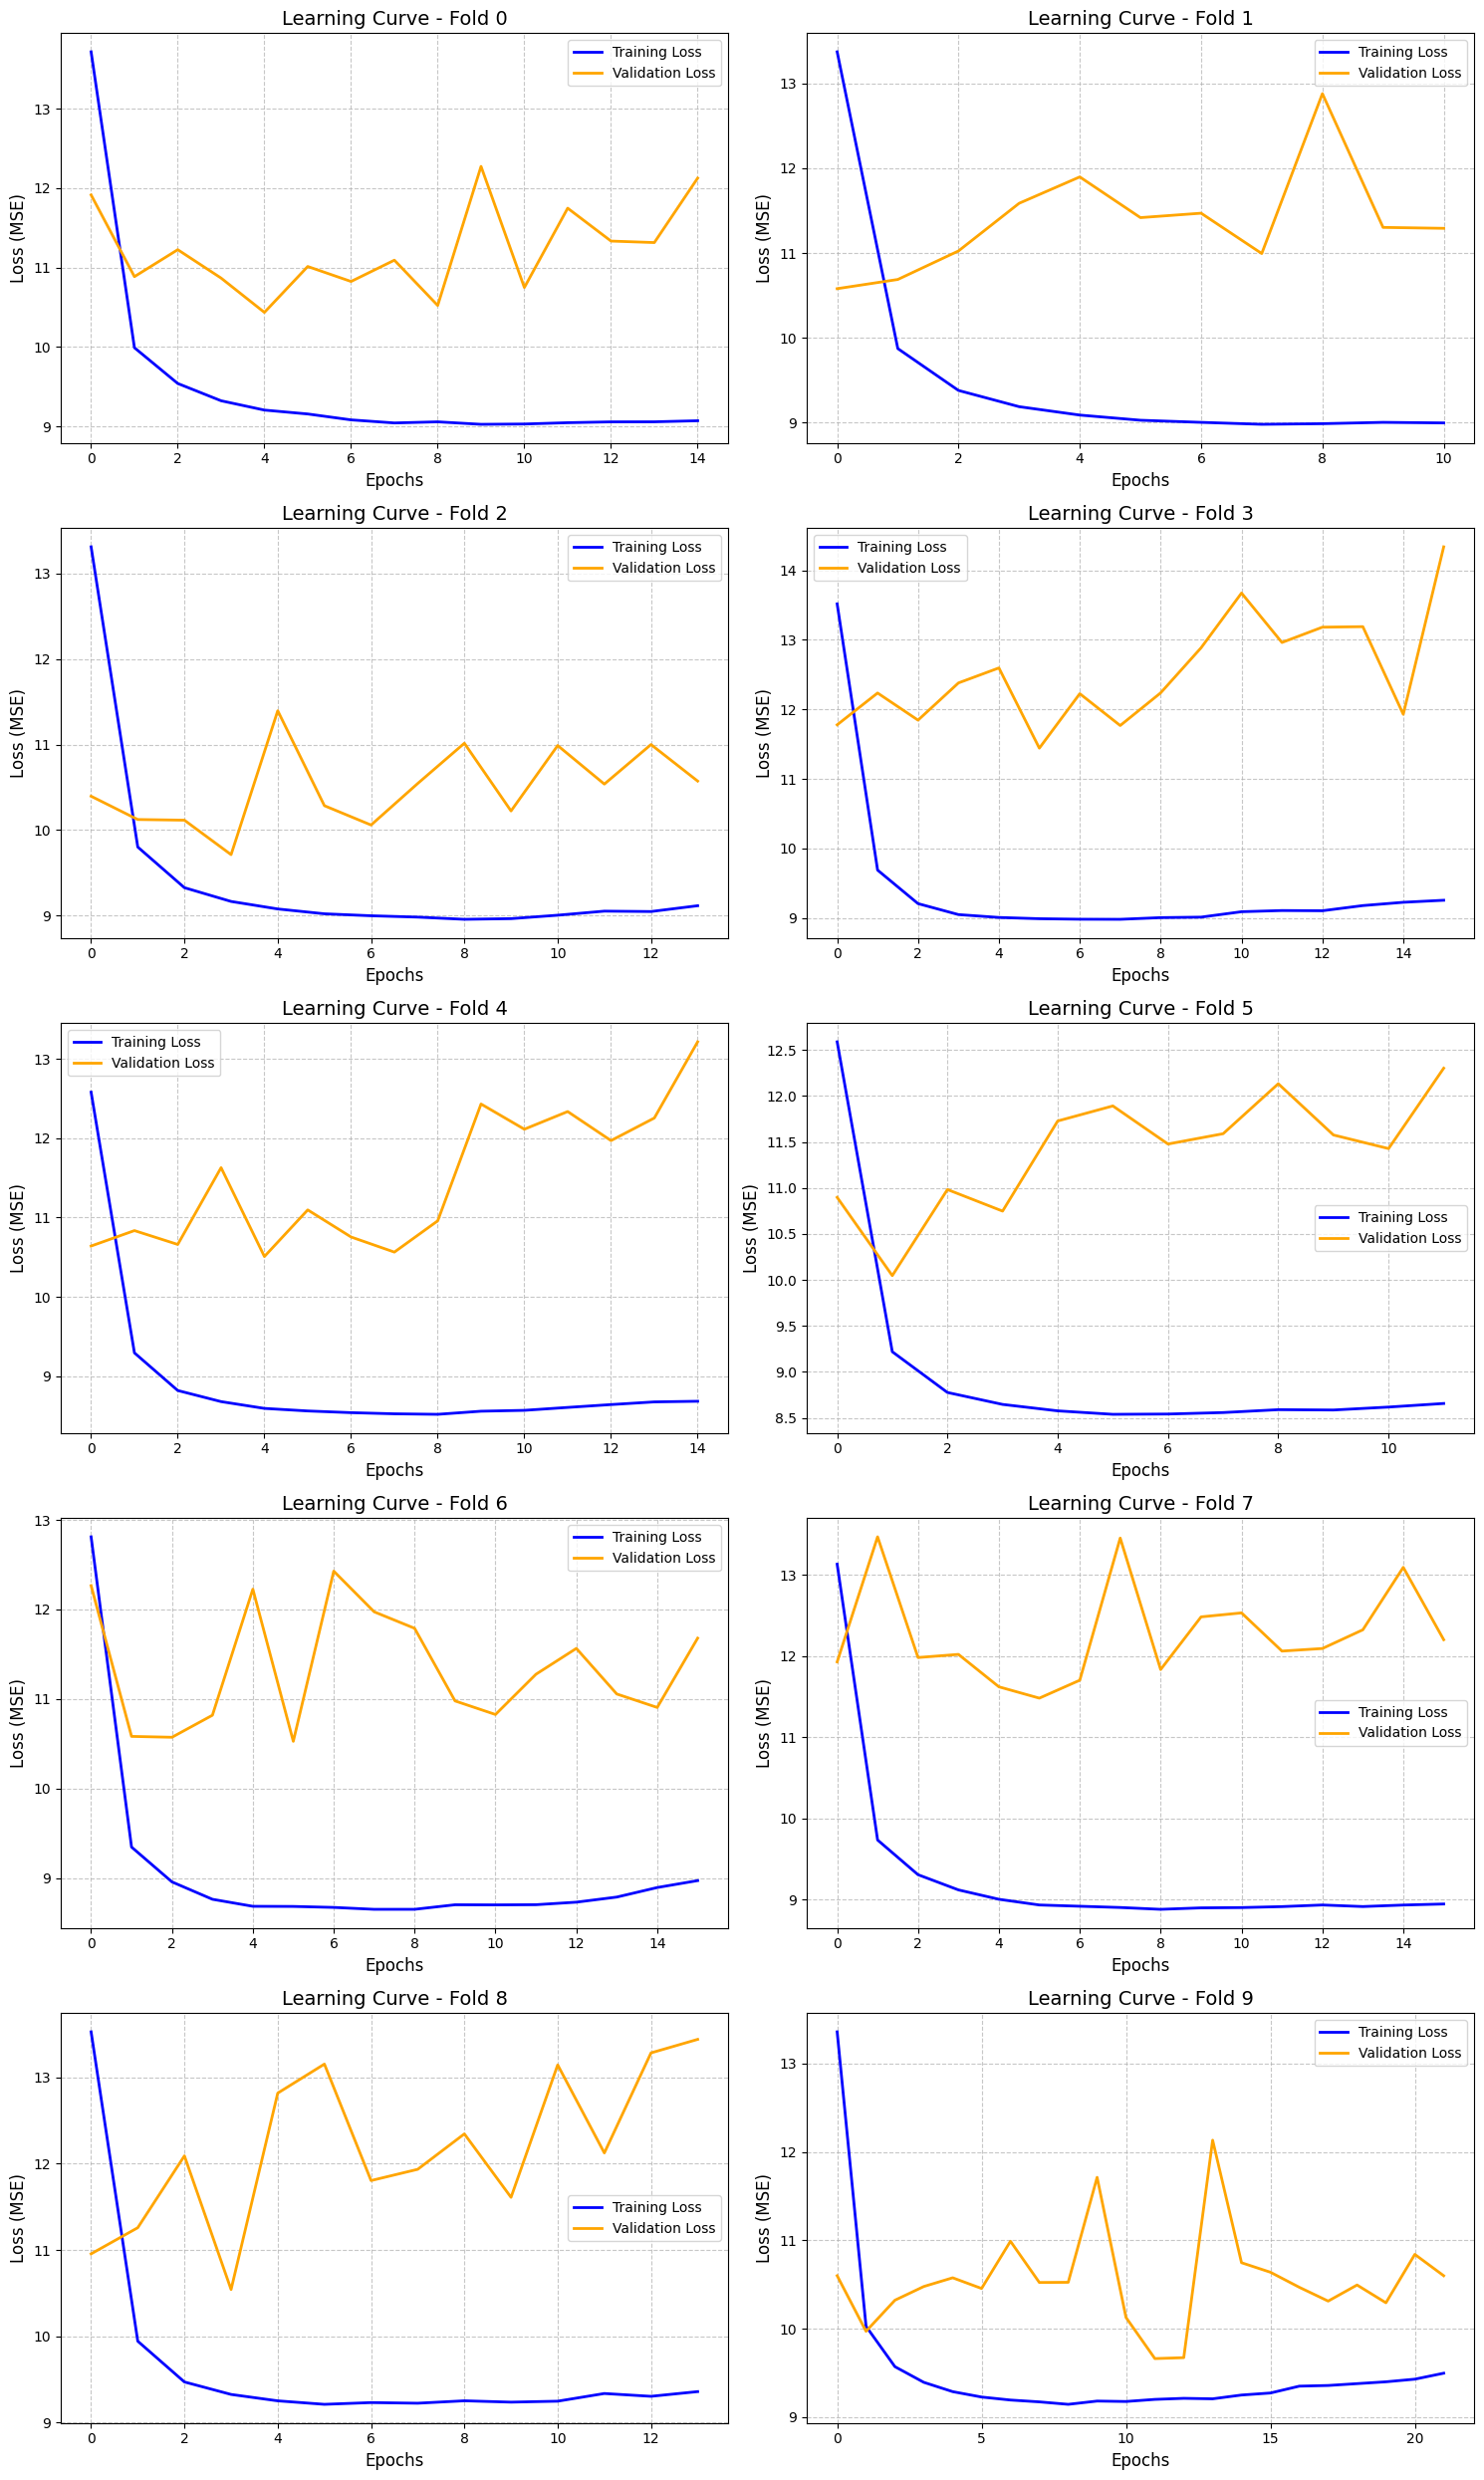

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_1_20260521_160615


In [12]:
k_fold_dict_1, save_dir_1 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_1")

### Experiment 2: batch_size = 256

=== Starting Experiment Pipeline: exp_2 ===
Created isolated environment at: experiments/exp_2_20260521_203007

--- Starting FOLD 0 ---


Early stopping at epoch 19
Train MSE: 7.700, Test MSE: 11.421, Train MAE: 2.147, Test MAE: 2.630

--- Starting FOLD 1 ---


Early stopping at epoch 15
Train MSE: 7.599, Test MSE: 10.075, Train MAE: 2.116, Test MAE: 2.494

--- Starting FOLD 2 ---


Early stopping at epoch 18
Train MSE: 7.033, Test MSE: 11.089, Train MAE: 2.024, Test MAE: 2.638

--- Starting FOLD 3 ---


Early stopping at epoch 14
Train MSE: 8.173, Test MSE: 12.840, Train MAE: 2.200, Test MAE: 2.748

--- Starting FOLD 4 ---


...

Early stopping at epoch 13
Train MSE: 7.752, Test MSE: 47.549, Train MAE: 2.115, Test MAE: 5.218

--- Starting FOLD 6 ---


Early stopping at epoch 15
Train MSE: 7.693, Test MSE: 36.319, Train MAE: 2.136, Test MAE: 4.439

--- Starting FOLD 7 ---


Early stopping at epoch 17
Train MSE: 7.459, Test MSE: 21.738, Train MAE: 2.115, Test MAE: 3.576

--- Starting FOLD 8 ---


Early stopping at epoch 15
Train MSE: 8.762, Test MSE: 13.136, Train MAE: 2.345, Test MAE: 3.011

--- Starting FOLD 9 ---


Early stopping at epoch 12
Train MSE: 7.973, Test MSE: 11.121, Train MAE: 2.133, Test MAE: 2.457

Execution 'exp_2' successfully completed in 2734.59s!
Generating Learning Curves...


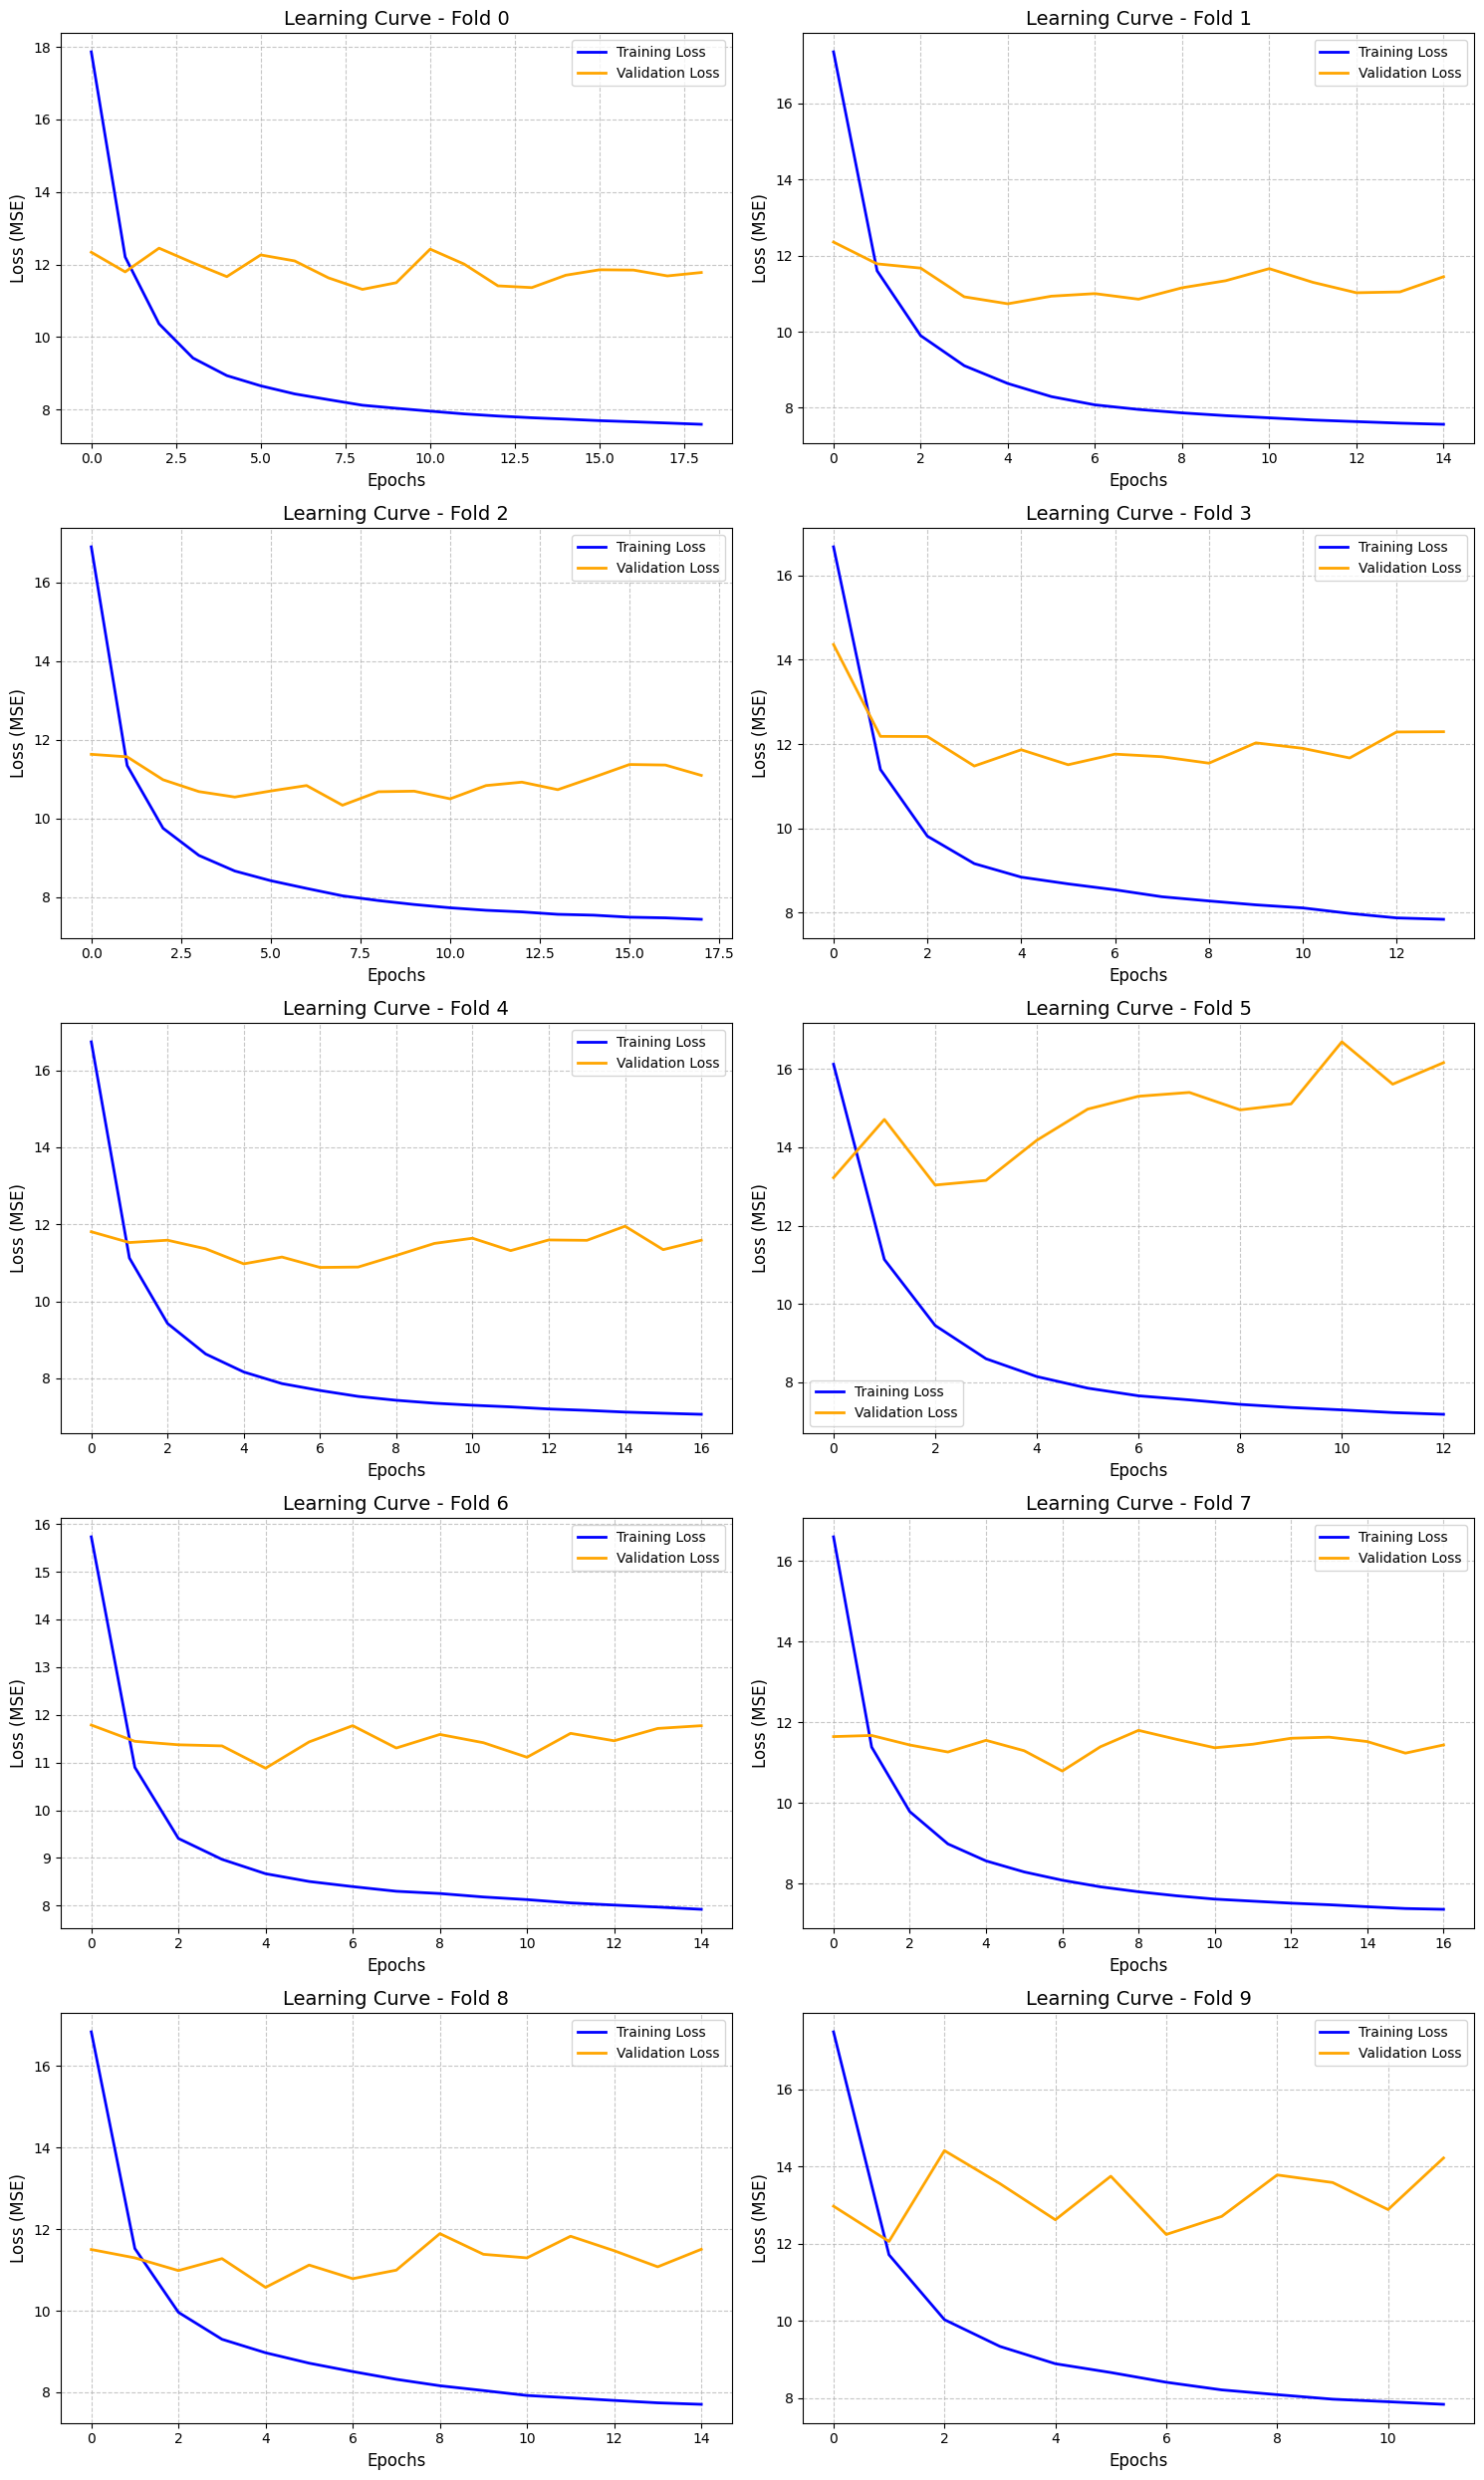

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_2_20260521_203007


In [12]:
k_fold_dict_2, save_dir_2 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=256, exp_name="exp_2")

In [12]:
print(k_fold_dict_2)

{'MAE': 3.370018347040911, 'MAPE': 0.25563652946529525, 'MSE': 21.30989163630756, 'predictions': array([12.59172058, 12.59132671, 12.59096813, ..., 11.67141724,
       11.66817188, 11.66492653], shape=(1905841,)), 'execution_time': 1914.3073630332947, 'histories': [{'train_loss': [np.float64(19.6568941647013), np.float64(12.013114592464108), np.float64(9.942472551181687), np.float64(8.96185637540316), np.float64(8.470467870734735), np.float64(8.195428006231163), np.float64(8.027416511033428), np.float64(7.923415067322), np.float64(7.843182303185606), np.float64(7.7853362569364615), np.float64(7.726424845311401)], 'val_loss': [12.658727645874023, 16.161497116088867, 14.178004264831543, 14.40145492553711, 14.3273344039917, 13.14233684539795, 13.764396667480469, 12.981348991394043, 13.274319648742676, 14.384540557861328, 14.998696327209473]}, {'train_loss': [np.float64(19.05168944048735), np.float64(11.796182740922593), np.float64(9.821664746691983), np.float64(8.822877163081358), np.floa

### Experiment 3: batch_size = 32 no flux

In [ ]:
X_3, y_3, feature_names_3 = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset.csv", orbit_path="Data/orbit_to_remove", keep_flux=False)

=== Starting Experiment Pipeline: exp_3 ===
Created isolated environment at: experiments/exp_3_20260520_195537

--- Starting FOLD 0 ---


Early stopping at epoch 15
Train MSE: 7.846, Test MSE: 13.905, Train MAE: 2.142, Test MAE: 2.798

--- Starting FOLD 1 ---


Early stopping at epoch 18
Train MSE: 7.556, Test MSE: 9.821, Train MAE: 2.080, Test MAE: 2.439

--- Starting FOLD 2 ---


Early stopping at epoch 19
Train MSE: 7.426, Test MSE: 11.135, Train MAE: 2.055, Test MAE: 2.652

--- Starting FOLD 3 ---


Early stopping at epoch 14
Train MSE: 7.656, Test MSE: 14.076, Train MAE: 2.082, Test MAE: 2.848

--- Starting FOLD 4 ---


...

Early stopping at epoch 14
Train MSE: 7.426, Test MSE: 46.958, Train MAE: 2.077, Test MAE: 4.990

--- Starting FOLD 6 ---


Early stopping at epoch 17
Train MSE: 7.582, Test MSE: 37.165, Train MAE: 2.100, Test MAE: 4.415

--- Starting FOLD 7 ---


Early stopping at epoch 11
Train MSE: 8.635, Test MSE: 19.927, Train MAE: 2.283, Test MAE: 3.361

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 9.230, Test MSE: 25.673, Train MAE: 2.392, Test MAE: 3.725

--- Starting FOLD 9 ---


Early stopping at epoch 17
Train MSE: 7.840, Test MSE: 13.368, Train MAE: 2.117, Test MAE: 2.707

Execution 'exp_3' successfully completed in 13315.90s!
Generating Learning Curves...


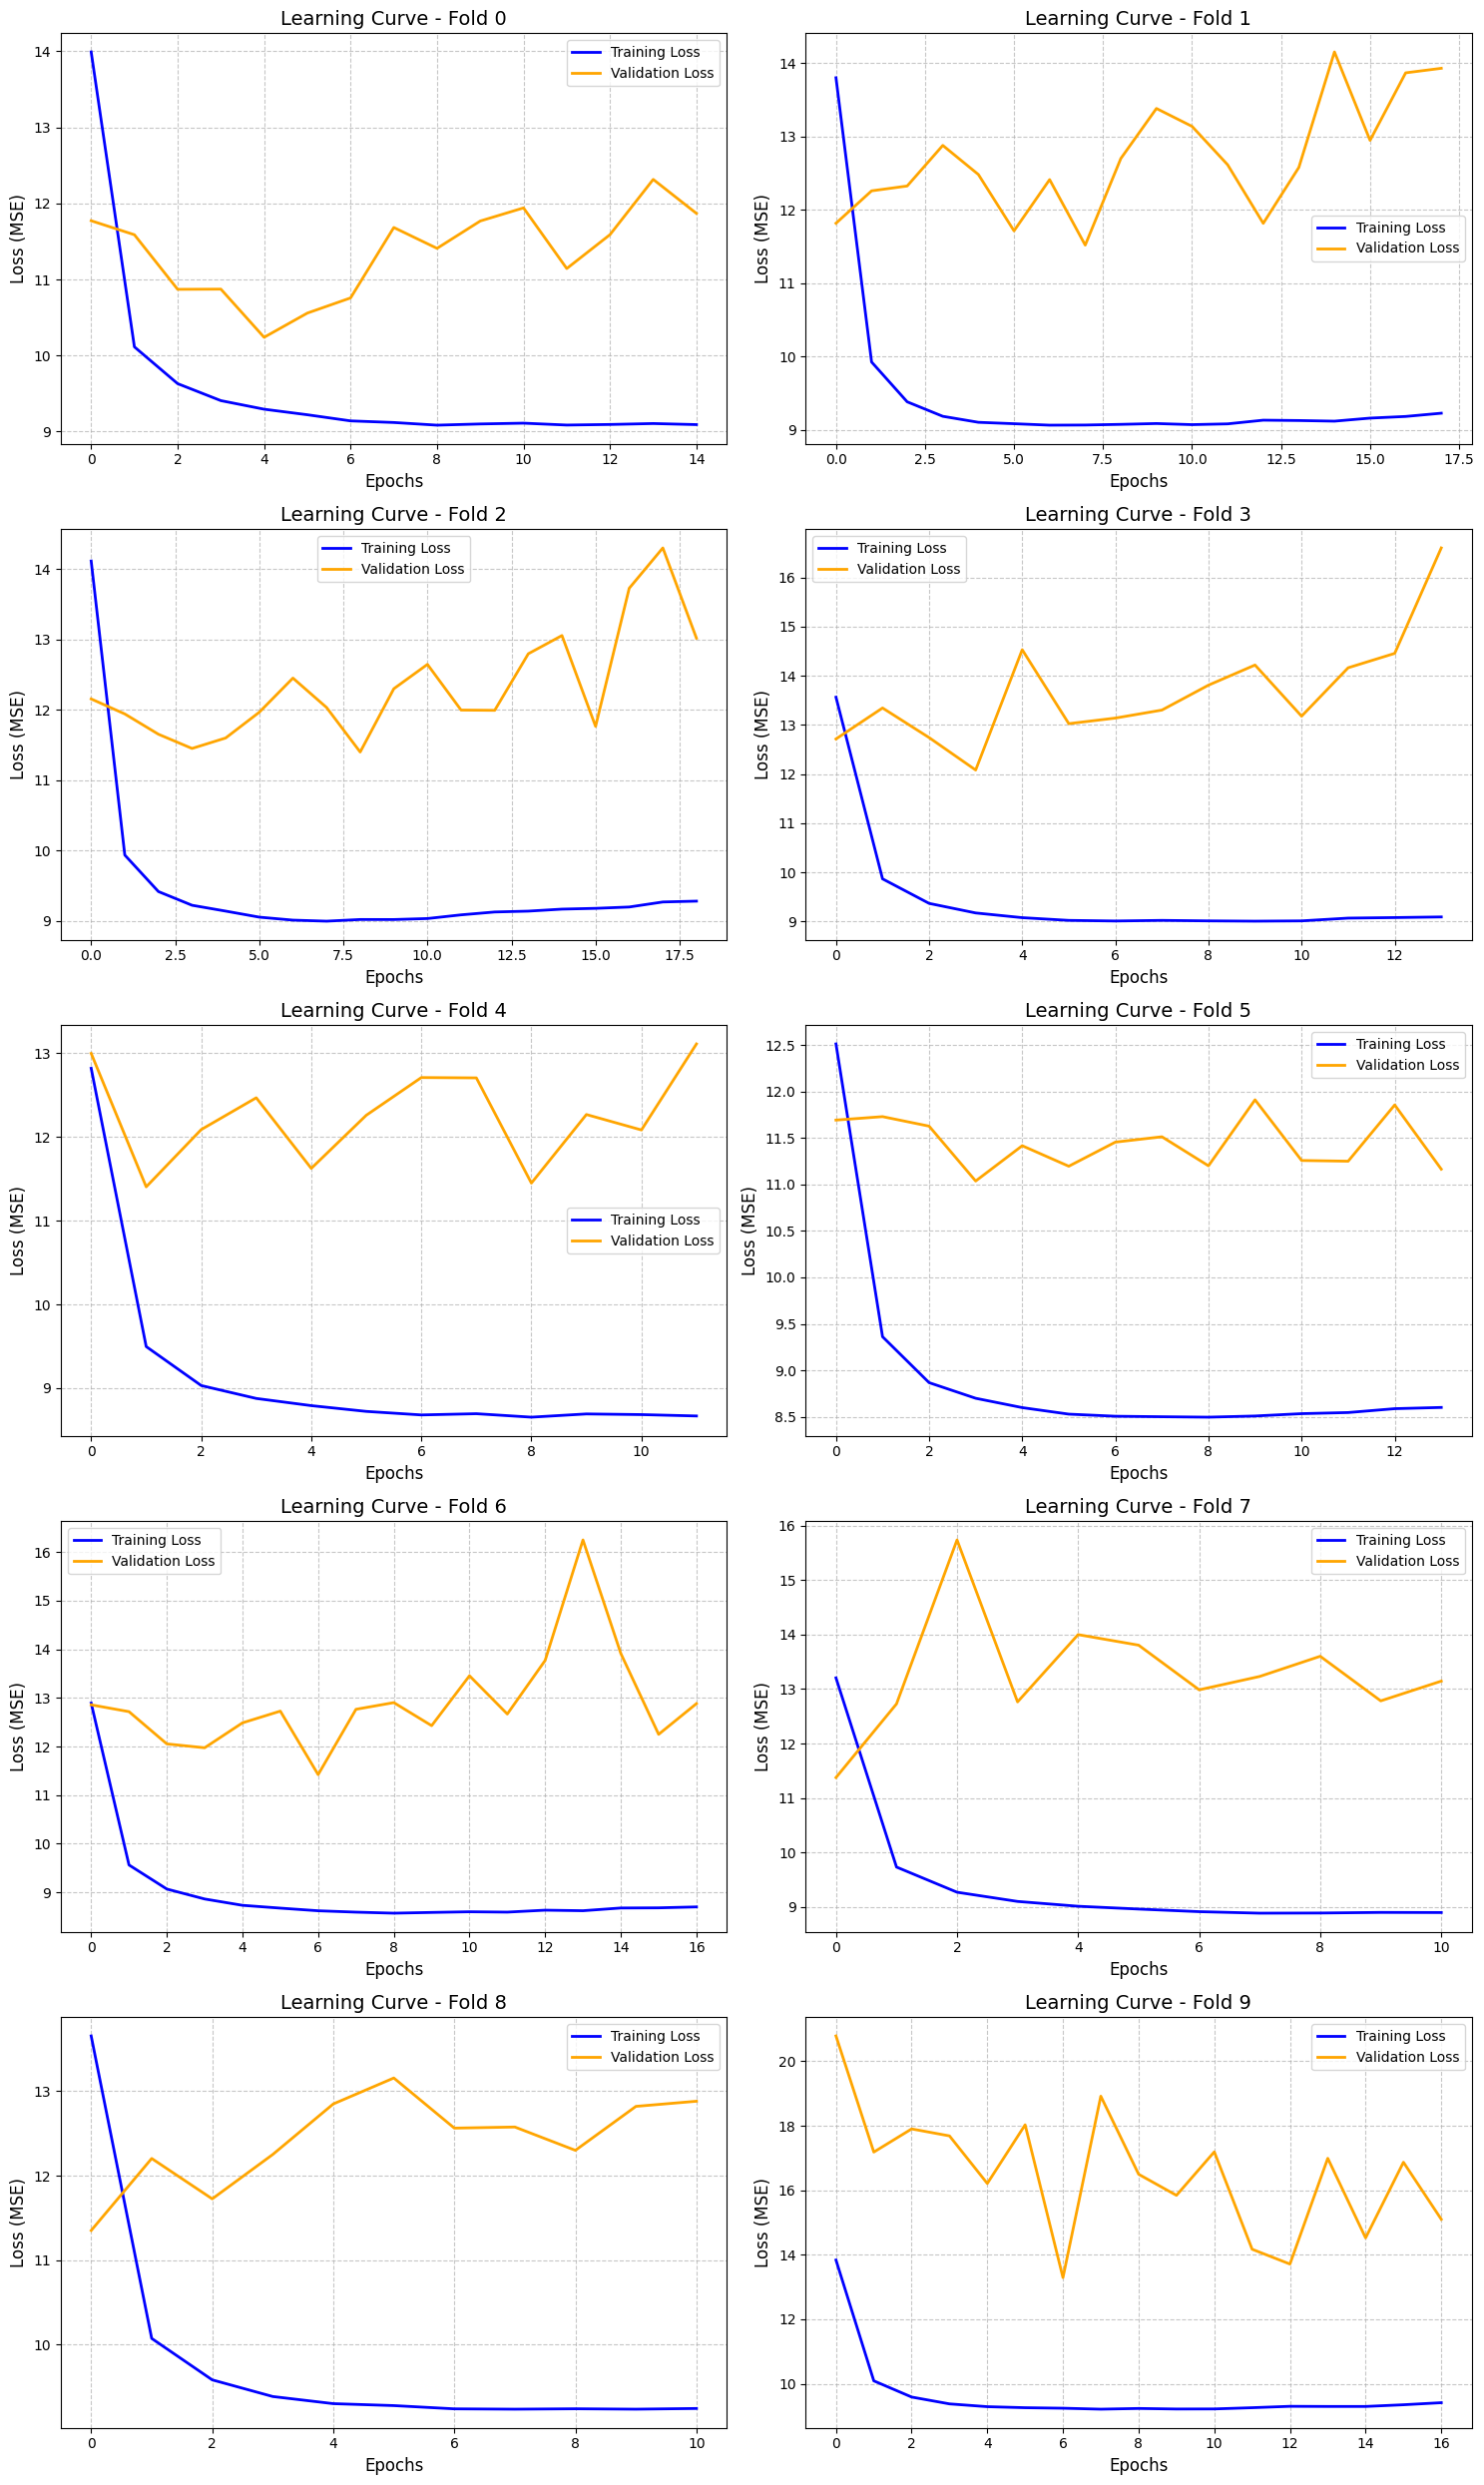

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_3_20260520_195537


In [12]:
k_fold_dict_3, save_dir_3 = pipeline(X_3, y_3, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_3")

### Comparison between corresponding tensorflow and pytorch outputs

=== Starting Experiment Comparison Analysis ===
Analisi exp tensorflow...
-> Rilevato formato TensorFlow. Estratti 10 valori MAE.
Analisi exp pytorch...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.


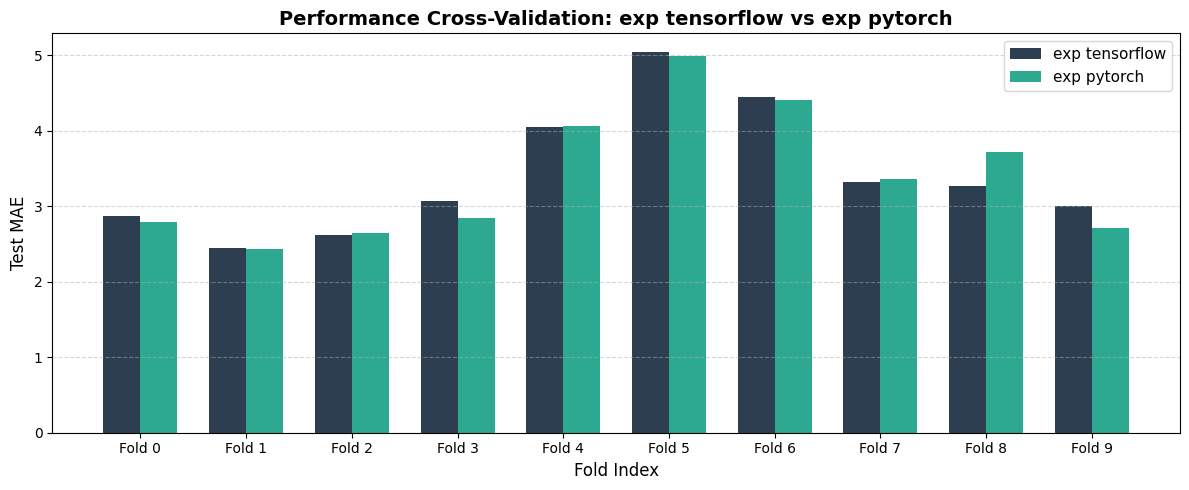

📊 Grafici salvati in:
   - ./comparison_20260523_exp_tensorflow_vs_exp_pytorch.png
   - ./comparison_20260523_exp_tensorflow_vs_exp_pytorch.pdf
=== Processo di Confronto Completato ===


In [11]:
compare_experiments_pipeline(
    "2026_05_17_23_49_OUTPUTS_ORIGINAL_KERAS_ALL.txt", 
    "experiments/exp_3_20260520_195537/MAE_exp_3.txt", 
    exp1_label="exp tensorflow",
    exp2_label="exp pytorch",
    output_dir=".", 
    show_plots=True
)

### Comparison between Exp 1 (with flux) and Exp 3 (no flux)

=== Starting Experiment Comparison Analysis ===
Analisi exp 1 (flux)...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.
Analisi exp 2 (no flux)...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.


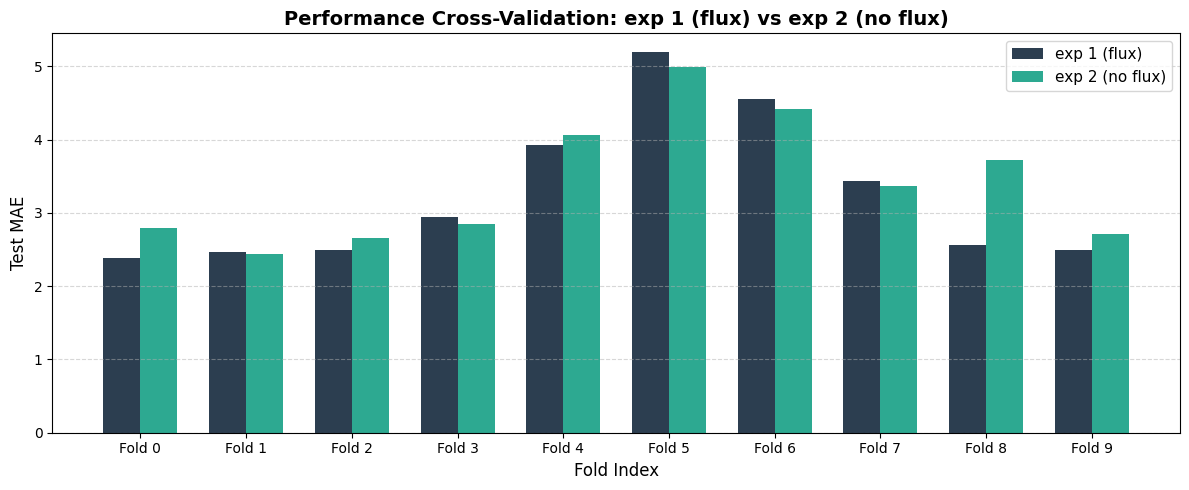

📊 Grafici salvati in:
   - ./comparison_20260523_exp_1_(flux)_vs_exp_2_(no_flux).png
   - ./comparison_20260523_exp_1_(flux)_vs_exp_2_(no_flux).pdf
=== Processo di Confronto Completato ===


In [12]:
compare_experiments_pipeline(
    "experiments/exp_1_20260521_160615/MAE_exp_1.txt", 
    "experiments/exp_3_20260520_195537/MAE_exp_3.txt", 
    exp1_label="exp 1 (flux)",
    exp2_label="exp 2 (no flux)",
    output_dir=".", 
    show_plots=True
)

Caricamento in corso dei dizionari dei risultati...
✅ Plot 1 salvato: comparison_plots/bar_chart_mse_20260523_164432 (.png e .pdf)


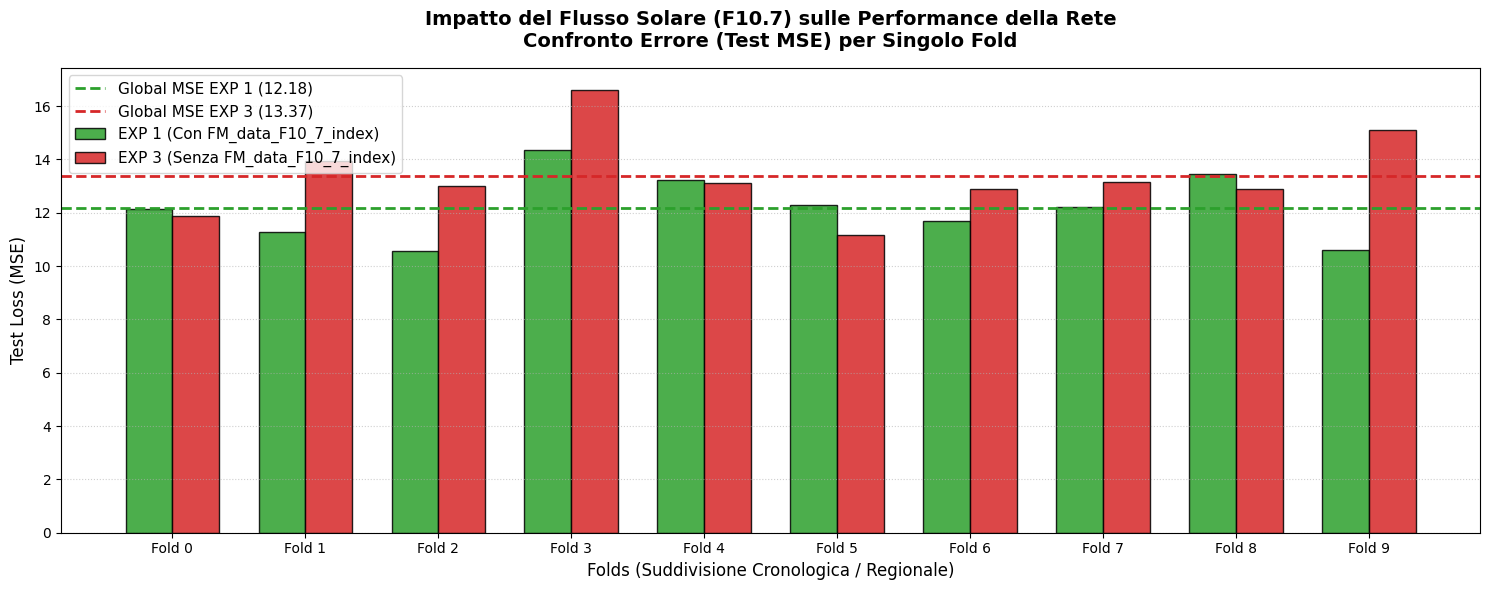

✅ Plot 2 salvato: comparison_plots/learning_curve_fold_8_20260523_164432 (.png e .pdf)


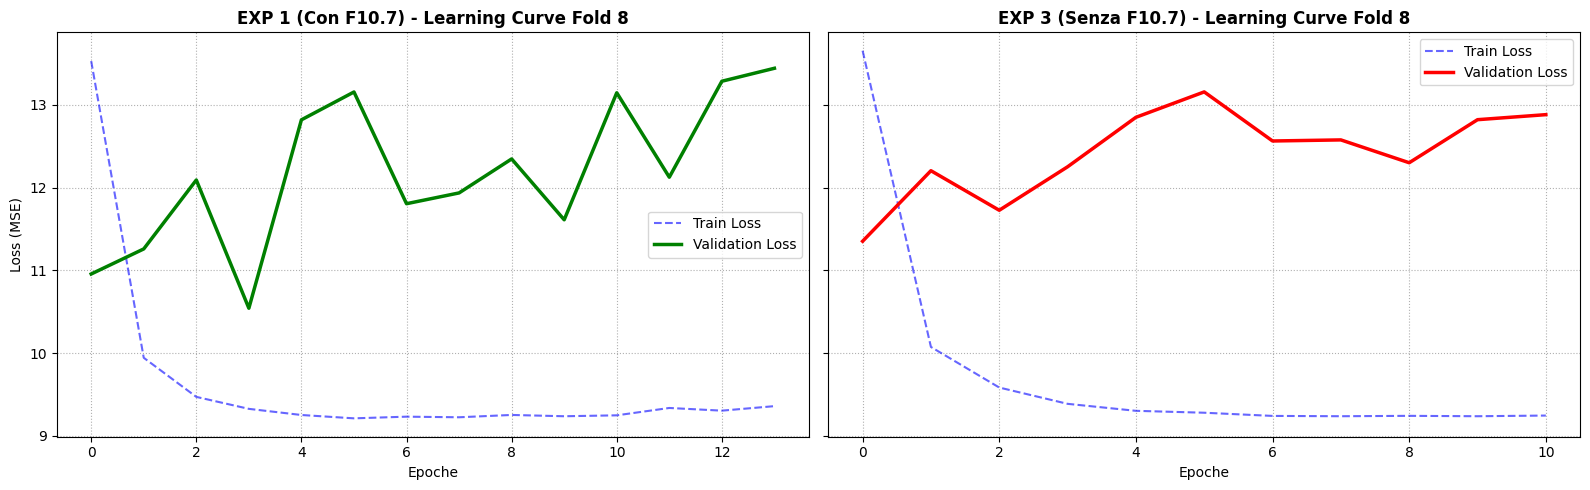

In [13]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

os.makedirs("comparison_plots", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# =====================================================================
# 1. DEFINIZIONE DEI PATH (Aggiorna i timestamp con quelli reali se differiscono)
# =====================================================================
path_exp1 = "experiments/exp_1_20260521_160615/results_dict.pkl"
path_exp3 = "experiments/exp_3_20260520_195537/results_dict.pkl"

# 2. CARICAMENTO DEI RISULTATI DA DISCO
print("Caricamento in corso dei dizionari dei risultati...")
with open(path_exp1, "rb") as f:
    dict_exp1 = pickle.load(f)

with open(path_exp3, "rb") as f:
    dict_exp3 = pickle.load(f)

# 3. ESTRAZIONE AUTOMATICA DEI TEST MSE DA 'HISTORIES'
# Poiché l'ultimo valore di val_loss corrisponde al punto di Early Stopping (il Test MSE del fold)
mse_fold_exp1 = [h['val_loss'][-1] for h in dict_exp1['histories']]
mse_fold_exp3 = [h['val_loss'][-1] for h in dict_exp3['histories']]

# Definizione parametri per il grafico a barre
num_folds = len(mse_fold_exp1)
folds = np.arange(num_folds)
width = 0.35  # Spessore delle barre affiancate

# =====================================================================
# PLOT 1: BAR CHART COMPARATIVO - TEST MSE PER FOLD
# =====================================================================
plt.figure(figsize=(15, 6))

# Barre EXP 1 (Con Flusso Solare)
plt.bar(folds - width/2, mse_fold_exp1, width, label='EXP 1 (Con FM_data_F10_7_index)', 
        color='#2ca02c', alpha=0.85, edgecolor='black')

# Barre EXP 3 (Senza Flusso Solare)
plt.bar(folds + width/2, mse_fold_exp3, width, label='EXP 3 (Senza FM_data_F10_7_index)', 
        color='#d62728', alpha=0.85, edgecolor='black')

# Linee orizzontali di riferimento per l'errore Globale Medio
global_mse_exp1 = np.mean(mse_fold_exp1)
global_mse_exp3 = np.mean(mse_fold_exp3)
plt.axhline(y=global_mse_exp1, color='#2ca02c', linestyle='--', linewidth=2, 
            label=f'Global MSE EXP 1 ({global_mse_exp1:.2f})')
plt.axhline(y=global_mse_exp3, color='#d62728', linestyle='--', linewidth=2, 
            label=f'Global MSE EXP 3 ({global_mse_exp3:.2f})')

# Personalizzazione estetica del grafico
plt.title("Impatto del Flusso Solare (F10.7) sulle Performance della Rete\nConfronto Errore (Test MSE) per Singolo Fold", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Folds (Suddivisione Cronologica / Regionale)', fontsize=12)
plt.ylabel('Test Loss (MSE)', fontsize=12)
plt.xticks(folds, [f"Fold {i}" for i in folds], fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()

# --- SALVATAGGIO PLOT 1 ---
base_name_plot1 = f"comparison_plots/bar_chart_mse_{timestamp}"
plt.savefig(f"{base_name_plot1}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{base_name_plot1}.pdf", format='pdf', bbox_inches='tight')
print(f"✅ Plot 1 salvato: {base_name_plot1} (.png e .pdf)")

plt.show()

# =====================================================================
# PLOT 2: FOCUS SUL FOLD CRITICO (FOLD 8) - LEARNING CURVES
# =====================================================================
# Il Fold 8 mostra l'impatto più drammatico nei tuoi log. Vediamo come sono andati i training.
fold_critico = 8

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Curve di EXP 1 (Con Flusso Solare)
h1 = dict_exp1['histories'][fold_critico]
axes[0].plot(h1['train_loss'], label='Train Loss', color='blue', alpha=0.6, linestyle='--')
axes[0].plot(h1['val_loss'], label='Validation Loss', color='green', linewidth=2.5)
axes[0].set_title(f"EXP 1 (Con F10.7) - Learning Curve Fold {fold_critico}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Loss (MSE)")
axes[0].grid(True, linestyle=':')
axes[0].legend()

# Curve di EXP 3 (Senza Flusso Solare)
h3 = dict_exp3['histories'][fold_critico]
axes[1].plot(h3['train_loss'], label='Train Loss', color='blue', alpha=0.6, linestyle='--')
axes[1].plot(h3['val_loss'], label='Validation Loss', color='red', linewidth=2.5)
axes[1].set_title(f"EXP 3 (Senza F10.7) - Learning Curve Fold {fold_critico}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoche")
axes[1].grid(True, linestyle=':')
axes[1].legend()

plt.tight_layout()

# --- SALVATAGGIO PLOT 2 ---
base_name_plot2 = f"comparison_plots/learning_curve_fold_{fold_critico}_{timestamp}"
plt.savefig(f"{base_name_plot2}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{base_name_plot2}.pdf", format='pdf', bbox_inches='tight')
print(f"✅ Plot 2 salvato: {base_name_plot2} (.png e .pdf)")

plt.show()

### Comparison between Exp 1 (batch_size = 32) and Exp 2 (batch_size = 256)

=== Starting Experiment Comparison Analysis ===
Analisi exp 1 (batch_size=32)...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.
Analisi exp 2 (batch_size=256)...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.


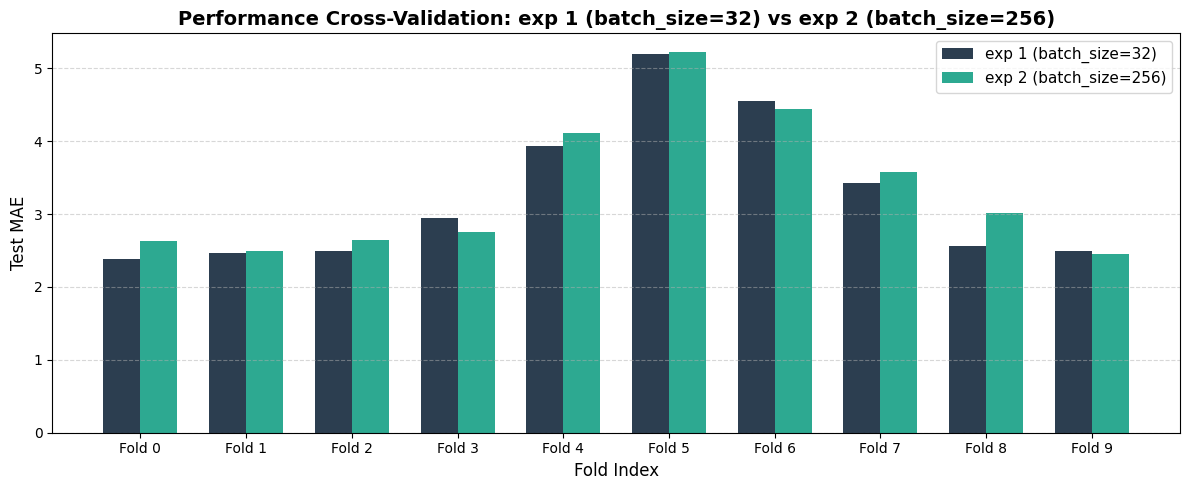

📊 Grafici salvati in:
   - ./comparison_20260523_exp_1_(batch_size=32)_vs_exp_2_(batch_size=256).png
   - ./comparison_20260523_exp_1_(batch_size=32)_vs_exp_2_(batch_size=256).pdf
=== Processo di Confronto Completato ===


In [14]:
compare_experiments_pipeline(
    "experiments/exp_1_20260521_160615/MAE_exp_1.txt", 
    "experiments/exp_2_20260521_203007/MAE_exp_2.txt", 
    exp1_label="exp 1 (batch_size=32)",
    exp2_label="exp 2 (batch_size=256)",
    output_dir=".", 
    show_plots=True
)

## SHAP on Neural Network

### SHAP on experiment 2: Macro vs Micro Error Analysis

#### Data extraction using indices from previous pipeline k fold cross validation

In [12]:
import re
import numpy as np
import os
from shap_utils.explain_with_shap import *

log_file_path = "experiments/exp_2_20260521_203007/MAE_exp_2.txt" 

# Dizionario per immagazzinare gli indici ricostruiti
extracted_test_indices = {}
fold_counter = 0

print("🔍 Lettura del log e ricostruzione degli indici in corso...")

# 1. Lettura dal file txt
if os.path.exists(log_file_path):
    with open(log_file_path, 'r') as file:
        for line in file:
            # Isoliamo le righe relative al TEST set
            if line.startswith("TEST:"):
                # re.findall(r'\d+', line) estrae tutti i gruppi di numeri ignorando parentesi e puntini
                numbers = [int(n) for n in re.findall(r'\d+', line)]
                
                if len(numbers) >= 2:
                    start_idx = numbers[0]   # Es. Fold 1: 190585
                    end_idx = numbers[-1]    # Es. Fold 1: 381168
                    
                    # Genera l'array continuo: [190585, 190586, ..., 381168]
                    extracted_test_indices[fold_counter] = np.arange(start_idx, end_idx + 1)
                
                fold_counter += 1
else:
    raise FileNotFoundError(f"File non trovato al percorso: {log_file_path}")

# 2. Assegnazione basata sull'indice globale
total_samples = len(X)
all_indices = np.arange(total_samples)

# ==========================================
# ESTRAZIONE DATI - FOLD 1 (Fold Sano)
# ==========================================
# Il Test set è l'array appena ricostruito
test_idx_f1 = extracted_test_indices[1]
# Il Train set è tutto il resto (Indici globali - Indici di test)
train_idx_f1 = np.setdiff1d(all_indices, test_idx_f1) 

X_train_fold1 = X[train_idx_f1]
X_test_fold1  = X[test_idx_f1]

# ==========================================
# ESTRAZIONE DATI - FOLD 5 (Fold Anomalo)
# ==========================================
test_idx_f5 = extracted_test_indices[5]
train_idx_f5 = np.setdiff1d(all_indices, test_idx_f5)

X_train_fold5 = X[train_idx_f5]
X_test_fold5  = X[test_idx_f5]
# Estraiamo anche i target reali per calcolare l'errore effettivo sui grafici Waterfall
y_test_fold5  = y[test_idx_f5]

print("✅ Operazione completata con successo! I dati estratti sono:")
print(f"   🔹 FOLD 1 -> Train: {X_train_fold1.shape}, Test: {X_test_fold1.shape}")
print(f"   🔹 FOLD 5 -> Train: {X_train_fold5.shape}, Test: {X_test_fold5.shape}")

🔍 Lettura del log e ricostruzione degli indici in corso...
✅ Operazione completata con successo! I dati estratti sono:
   🔹 FOLD 1 -> Train: (1715257, 19), Test: (190584, 19)
   🔹 FOLD 5 -> Train: (1715257, 19), Test: (190584, 19)


In [13]:
# 0. Estrazione preliminare dei nomi delle feature (con Solar Flux incluso)
feature_names_2 = extract_feature_names(dataset_path="Data/MARSIS_historical_dataset.csv", keep_flux=True)
input_dim_2 = len(feature_names_2)

#### Fold 1 and Fold 5


--- 1A. Esecuzione SHAP su FOLD 1 (Zona Regolare - Performance Buone) ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260521_203007/model_exp_2_1.pth | Scaler: experiments/exp_2_20260521_203007/scaler_chrono_exp_2_1.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
Generating plot...
SHAP calculation completed.

--- 1B. Esecuzione SHAP su FOLD 5 (Zona Problematica - Errore Elevato) ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260521_203007/model_exp_2_5.pth | Scaler: experiments/exp_2_20260521_203007/scaler_chrono_exp_2_5.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
Generating plot...
SHAP calculation completed.



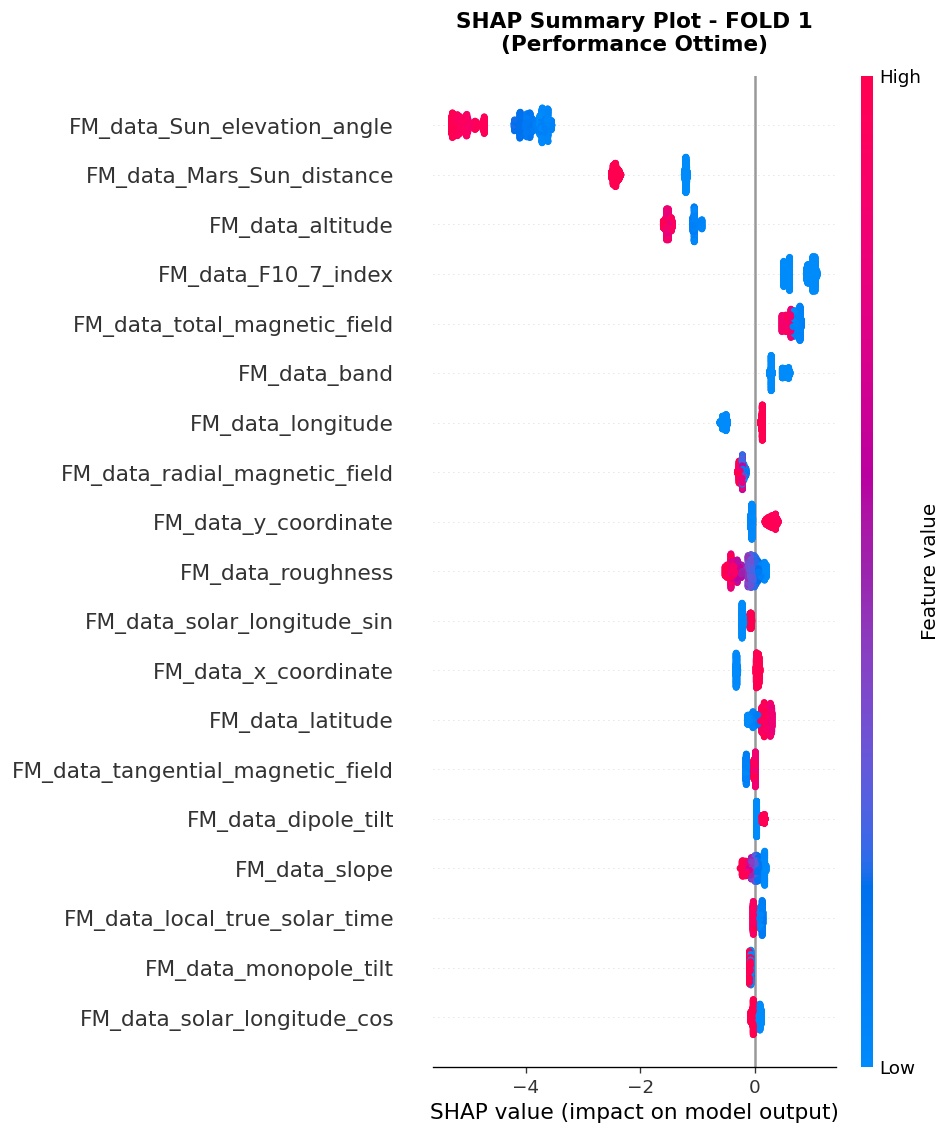
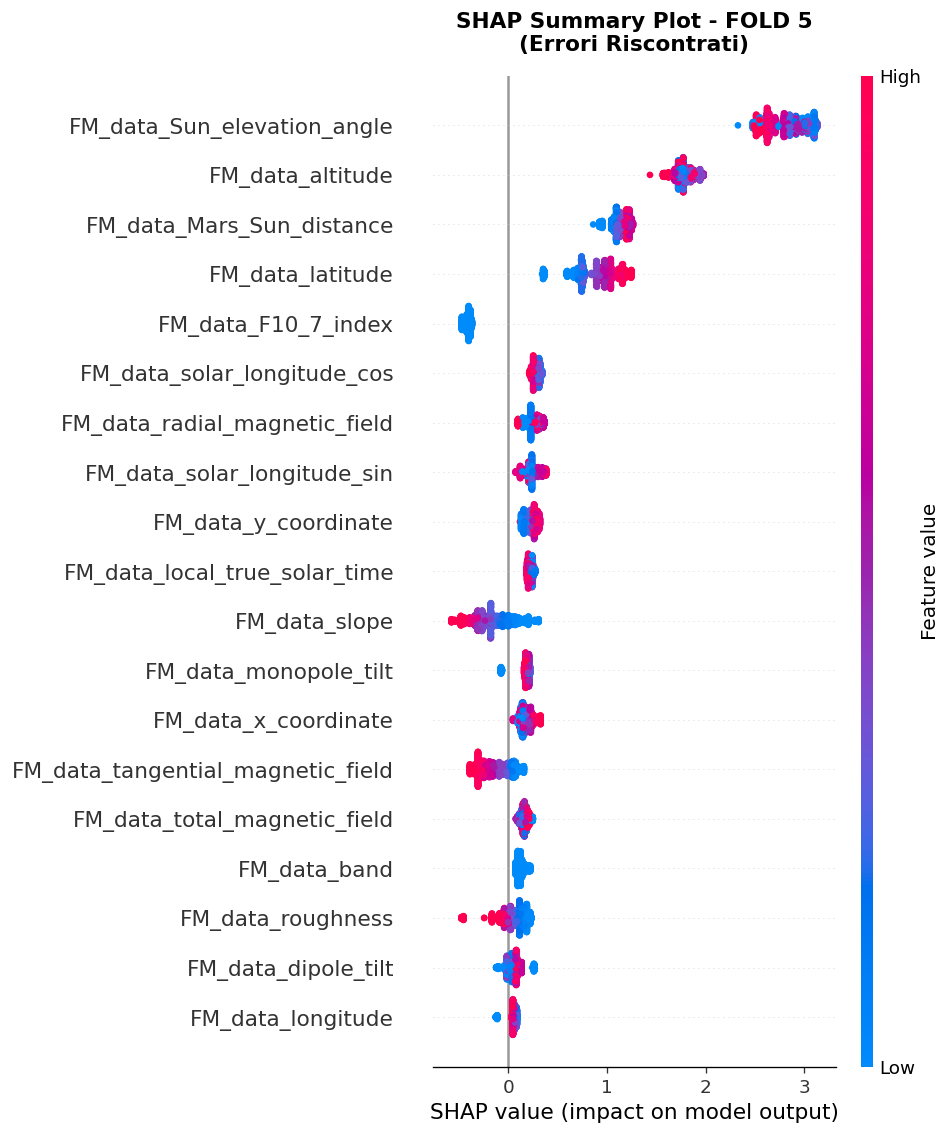

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap

from datetime import datetime

# Generiamo il timestamp unico e creiamo la cartella per i plot di SHAP
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_plots", exist_ok=True)

# =====================================================================
# STEP 1: MACRO ANALYSIS - REGION COMPARISON (FOLD 1 vs FOLD 5)
# =====================================================================

print("\n--- 1A. Esecuzione SHAP su FOLD 1 (Zona Regolare - Performance Buone) ---")
model_fold1 = NeurNet(input_dim=input_dim_2)
weights_f1 = "experiments/exp_2_20260521_203007/model_exp_2_1.pth"
scaler_f1 = "experiments/exp_2_20260521_203007/scaler_chrono_exp_2_1.save"

shap_values_f1, X_test_scaled_f1, explainer_f1 = explain_with_shap(
    model=model_fold1,
    weights_path=weights_f1,
    scaler_path=scaler_f1,
    X_background_raw=X_train_fold1,  # Matrice grezza di train del Fold 1
    X_test_raw=X_test_fold1,          # Matrice grezza di test del Fold 1
    feature_names=feature_names_2,
    bg_limit=500,
    test_limit=2000
)

print("\n--- 1B. Esecuzione SHAP su FOLD 5 (Zona Problematica - Errore Elevato) ---")
model_fold5 = NeurNet(input_dim=input_dim_2)
weights_f5 = "experiments/exp_2_20260521_203007/model_exp_2_5.pth"
scaler_f5 = "experiments/exp_2_20260521_203007/scaler_chrono_exp_2_5.save"

shap_values_f5, X_test_scaled_f5, explainer_f5 = explain_with_shap(
    model=model_fold5,
    weights_path=weights_f5,
    scaler_path=scaler_f5,
    X_background_raw=X_train_fold5,  # Matrice grezza di train del Fold 5
    X_test_raw=X_test_fold5,          # Matrice grezza di test del Fold 5
    feature_names=feature_names_2,
    bg_limit=500,
    test_limit=2000
)

# 1. Generiamo la PRIMA immagine (Totalmente indipendente)
fig1 = plt.figure(figsize=(9, 5.5))
shap.summary_plot(shap_values_f1, X_test_scaled_f1, feature_names=feature_names_2, show=False)
plt.title("SHAP Summary Plot - FOLD 1\n(Performance Ottime)", fontsize=13, fontweight='bold', pad=15)

base_f1 = f"shap_plots/shap_summary_fold1_{timestamp}"
fig1.savefig(f"{base_f1}.png", dpi=600, bbox_inches='tight')
fig1.savefig(f"{base_f1}.pdf", format='pdf', bbox_inches='tight')

html_fold1 = fig_to_html_element(fig1)

# 2. Generiamo la SECONDA immagine (Totalmente indipendente)
fig2 = plt.figure(figsize=(9, 5.5))
shap.summary_plot(shap_values_f5, X_test_scaled_f5, feature_names=feature_names_2, show=False)
plt.title("SHAP Summary Plot - FOLD 5\n(Errori Riscontrati)", fontsize=13, fontweight='bold', pad=15)

base_f5 = f"shap_plots/shap_summary_fold5_{timestamp}"
fig2.savefig(f"{base_f5}.png", dpi=600, bbox_inches='tight')
fig2.savefig(f"{base_f5}.pdf", format='pdf', bbox_inches='tight')

html_fold5 = fig_to_html_element(fig2)


# 3. Affianchiamo le due immagini sulla stessa riga usando un container Flexbox
html_container = f"""
<div style="display: flex; justify-content: space-between; align-items: flex-start; width: 100%;">
    {html_fold1}
    {html_fold5}
</div>
"""

# Rendering finale nel notebook
display(HTML(html_container))

#### Micro analysis


--- 2. Estrazione e Analisi dei peggiori campioni del Fold 5 ---
Indici dei campioni più problematici nel Fold 5: [1663 1665 1664]
Errori assoluti corrispondenti: [13.4509449  13.34175682 13.29695511]

Generazione Waterfall Plot per il campione ad alto errore (Indice: 1663)...
   💾 Grafici salvati in: shap_single_plots/waterfall_fold5_sample_1663_20260523_164703 (.png/.pdf)


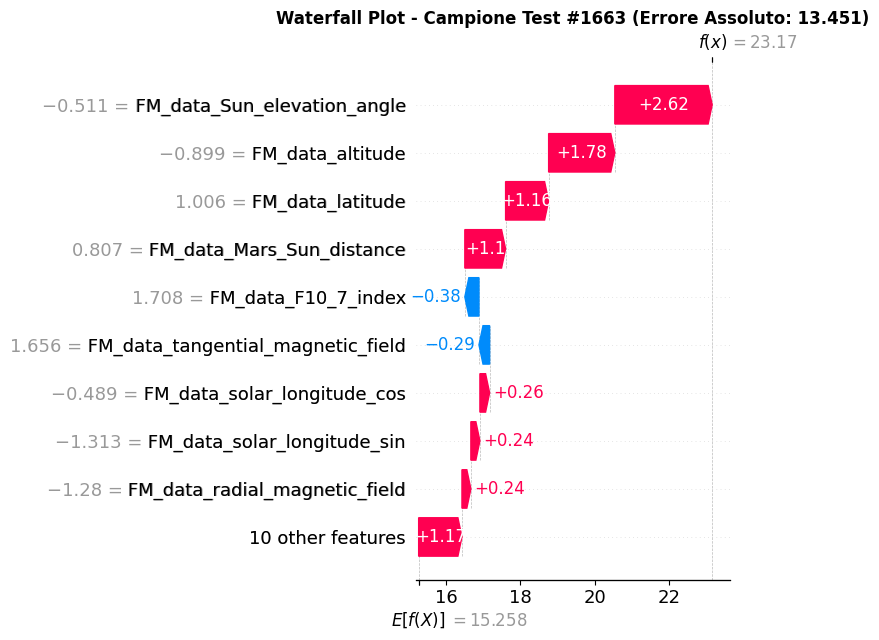


Generazione Waterfall Plot per il campione ad alto errore (Indice: 1665)...
   💾 Grafici salvati in: shap_single_plots/waterfall_fold5_sample_1665_20260523_164703 (.png/.pdf)


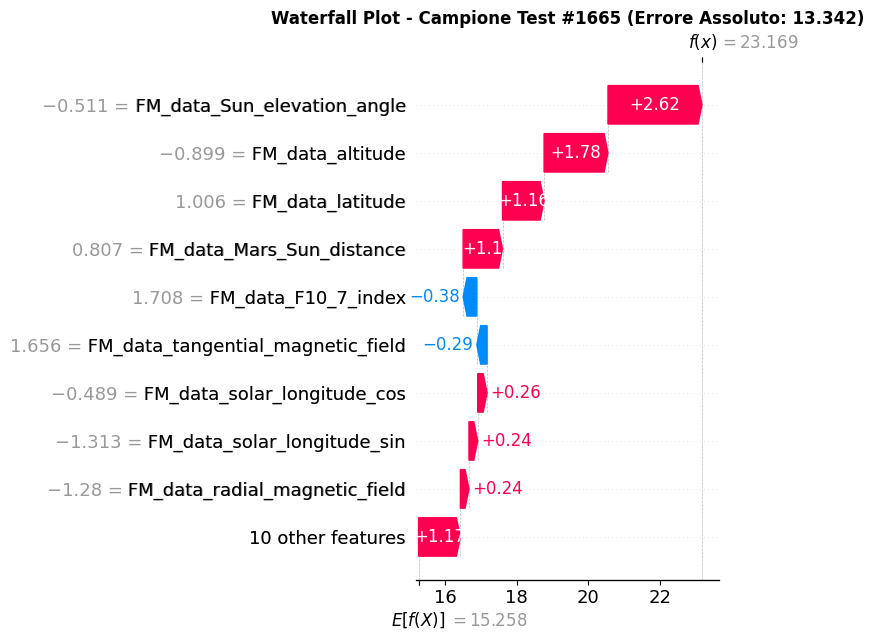


Generazione Waterfall Plot per il campione ad alto errore (Indice: 1664)...
   💾 Grafici salvati in: shap_single_plots/waterfall_fold5_sample_1664_20260523_164703 (.png/.pdf)


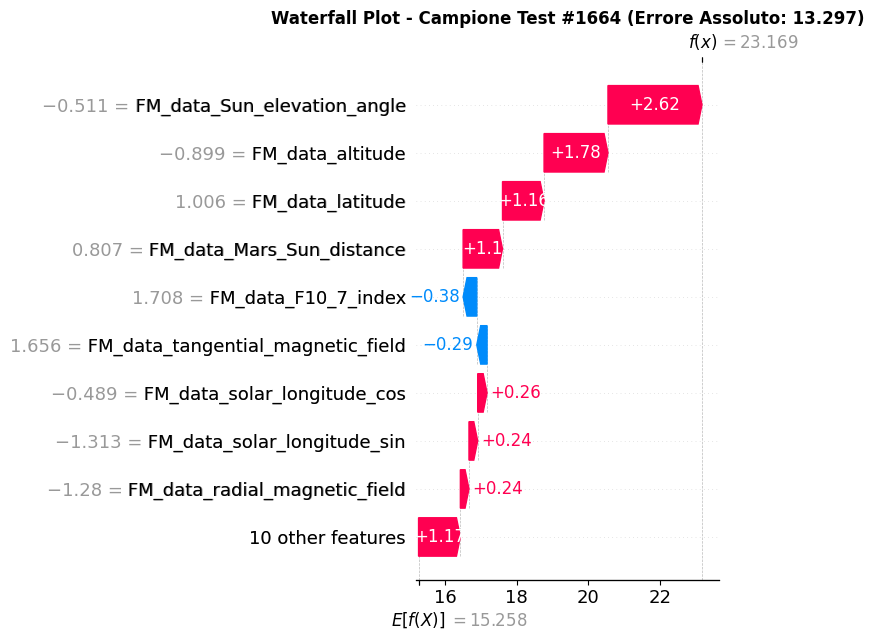

In [20]:
from datetime import datetime
import os

# Generiamo il timestamp unico per questa esecuzione e creiamo la cartella
timestamp_single = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_single_plots", exist_ok=True)

# =====================================================================
# STEP 2: ANALISI MICROSCOPICA - ISOLAMENTO ANOMALIE & WATERFALL PLOT
# =====================================================================
print("\n--- 2. Estrazione e Analisi dei peggiori campioni del Fold 5 ---")

# Generazione delle predizioni del modello per calcolare l'errore reale residuo
model_fold5.to("cpu")
model_fold5.eval()
with torch.no_grad():
    # Convertiamo i dati di test già normalizzati in tensore pytorch
    tensor_test_f5 = torch.tensor(X_test_scaled_f5, dtype=torch.float32)
    # Calcolo output della rete e conversione in vettore numpy flat
    y_pred_f5 = model_fold5(tensor_test_f5).cpu().numpy().flatten()

# Calcolo del residuo assoluto su scala reale: Errore = |Y_predicton - Y_true|
# Assicurati che y_test_fold5 sia un array monodimensionale di numpy
limit = len(y_pred_f5)
absolute_errors = np.abs(y_pred_f5 - y_test_fold5[:limit].flatten())

# Estrazione degli indici dei 3 campioni con l'errore più alto (ordinamento crescente, prendi gli ultimi 3)
worst_samples_indices = np.argsort(absolute_errors)[-3:][::-1]

print(f"Indici dei campioni più problematici nel Fold 5: {worst_samples_indices}")
print(f"Errori assoluti corrispondenti: {absolute_errors[worst_samples_indices]}")

# Estrazione del valore atteso (E[f(x)]) di base dal DeepExplainer
base_value = explainer_f5.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

# Generazione dei Waterfall Plot locali per ogni anomalia isolata
for idx in worst_samples_indices:
    print(f"\nGenerazione Waterfall Plot per il campione ad alto errore (Indice: {idx})...")
    
    # Chirurgia SHAP: impacchettiamo i vettori dentro un oggetto contenitore shap.Explanation
    explanation_object = shap.Explanation(
        values=shap_values_f5[idx], 
        base_values=base_value, 
        data=X_test_scaled_f5[idx], 
        feature_names=feature_names_2
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(explanation_object, show=False)
    plt.title(f"Waterfall Plot - Campione Test #{idx} (Errore Assoluto: {absolute_errors[idx]:.3f})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    # --- CHIRURGIA DI SALVATAGGIO AD ALTA QUALITÀ ---
    # Includiamo 'idx' nel nome per evitare che i 3 grafici si sovrascrivano a vicenda
    base_name = f"shap_single_plots/waterfall_fold5_sample_{idx}_{timestamp_single}"
    plt.savefig(f"{base_name}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name}.pdf", format='pdf', bbox_inches='tight')
    print(f"   💾 Grafici salvati in: {base_name} (.png/.pdf)")
    
    plt.show()

#### Investigating Fold 9


--- Estrazione Dati per il FOLD 9 ---
 🔹 FOLD 9 -> Train: (1715257, 19), Test: (190584, 19)

--- Esecuzione SHAP su FOLD 9 ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260521_203007/model_exp_2_9.pth | Scaler: experiments/exp_2_20260521_203007/scaler_chrono_exp_2_9.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
Generating plot...
SHAP calculation completed.
✅ Variabili shap_values_f9 e X_test_scaled_f9 generate con successo e pronte per il Dependence Plot!
✅ Variabili shap_values_f9 e X_test_scaled_f9 generate con successo!

--- 2. Analisi SHAP della singola feature (Flusso Solare) sul Fold 9 ---
Generazione dello SHAP Dependence Plot per 'FM_data_F10_7_index'...
    💾 Dependence Plot salvato.


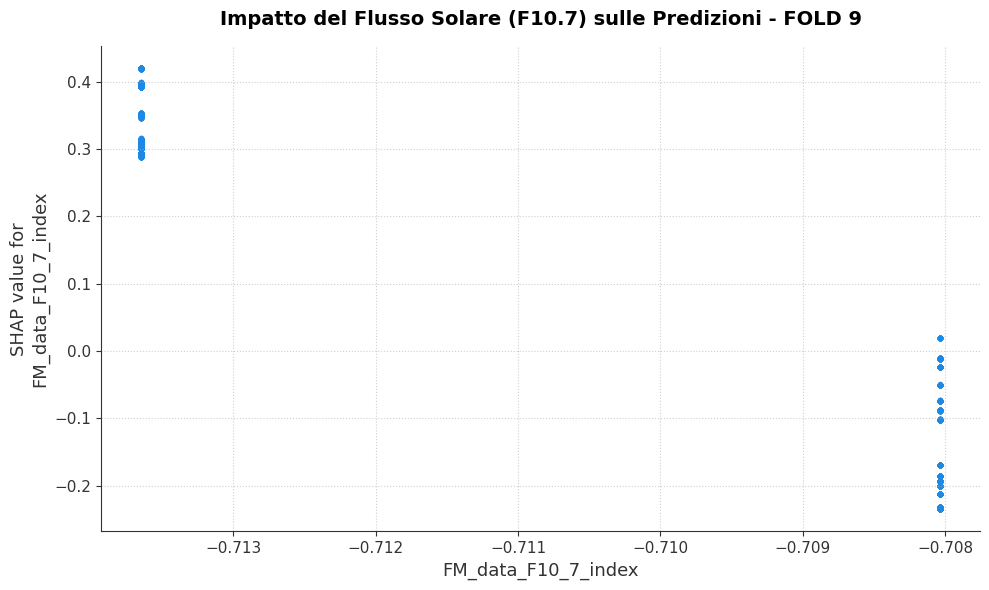


--- 3. Estrazione e Analisi dei peggiori campioni del Fold 9 (Waterfall) ---
Indici dei campioni più problematici nel Fold 9: [1812 1809 1886]
Errori assoluti corrispondenti: [7.72433853 7.01270294 6.87319183]
Generazione Waterfall Plot per il campione ad alto errore del Fold 9 (Indice: 1812)...
    💾 Grafico a cascata salvato in: shap_single_plots/waterfall_fold9_sample_1812_20260523_174824 (.png/.pdf)


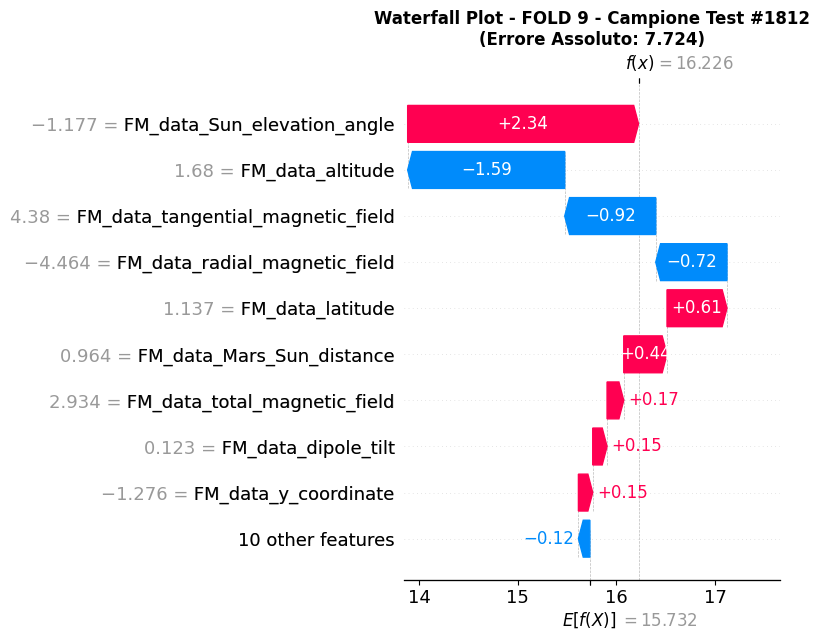

Generazione Waterfall Plot per il campione ad alto errore del Fold 9 (Indice: 1809)...
    💾 Grafico a cascata salvato in: shap_single_plots/waterfall_fold9_sample_1809_20260523_174824 (.png/.pdf)


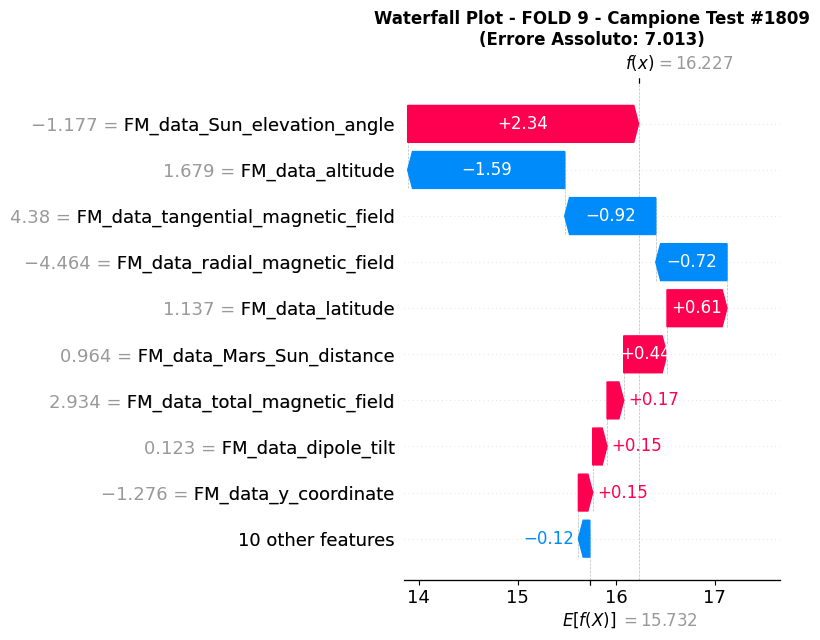

Generazione Waterfall Plot per il campione ad alto errore del Fold 9 (Indice: 1886)...
    💾 Grafico a cascata salvato in: shap_single_plots/waterfall_fold9_sample_1886_20260523_174824 (.png/.pdf)


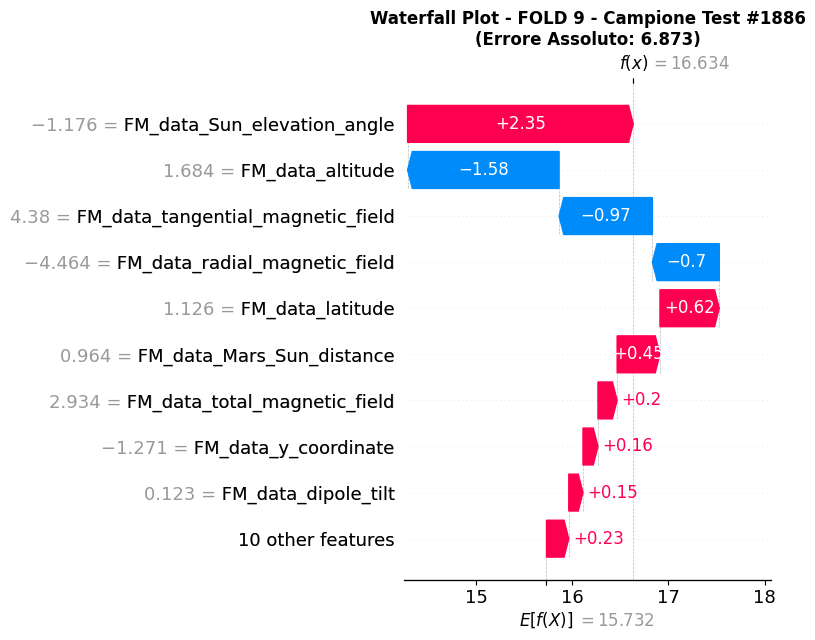

In [15]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap
from datetime import datetime
from shap_utils.explain_with_shap import *

# =====================================================================
# STEP 1.5: PREPARAZIONE ESTRAZIONE DATI E SHAP PER IL FOLD 9
# =====================================================================
print("\n--- Estrazione Dati per il FOLD 9 ---")

# 1. Ricostruzione delle matrici di Train e Test specifiche per il Fold 9
# (Assumendo che 'extracted_test_indices', 'X' e 'all_indices' siano già 
# disponibili in memoria dalle celle precedenti del tuo notebook)
test_idx_f9 = extracted_test_indices[9]
train_idx_f9 = np.setdiff1d(all_indices, test_idx_f9)

X_train_fold9 = X[train_idx_f9]
X_test_fold9  = X[test_idx_f9]
y_test_fold9 = y[test_idx_f9]

print(f" 🔹 FOLD 9 -> Train: {X_train_fold9.shape}, Test: {X_test_fold9.shape}")

print("\n--- Esecuzione SHAP su FOLD 9 ---")

# 2. Inizializzazione della rete
model_fold9 = NeurNet(input_dim=input_dim_2)

# 3. Path ai pesi e allo scaler del Fold 9 
# (Ho dedotto i nomi seguendo la logica dei tuoi path precedenti. 
# Verifica che il suffisso sia _9.pth e _9.save!)
weights_f9 = "experiments/exp_2_20260521_203007/model_exp_2_9.pth"
scaler_f9  = "experiments/exp_2_20260521_203007/scaler_chrono_exp_2_9.save"

# 4. Generazione degli SHAP values tramite la tua funzione di utility
shap_values_f9, X_test_scaled_f9, explainer_f9 = explain_with_shap(
    model=model_fold9,
    weights_path=weights_f9,
    scaler_path=scaler_f9,
    X_background_raw=X_train_fold9,  # La matrice grezza di train per il background
    X_test_raw=X_test_fold9,         # La matrice grezza di test da spiegare
    feature_names=feature_names_2,
    bg_limit=500,                    # Limite background (come nei fold precedenti)
    test_limit=2000                  # Limite test (come nei fold precedenti)
)

print("✅ Variabili shap_values_f9 e X_test_scaled_f9 generate con successo e pronte per il Dependence Plot!")

print("✅ Variabili shap_values_f9 e X_test_scaled_f9 generate con successo!")

# Generiamo il timestamp unico e creiamo la cartella dedicata
timestamp_single_9 = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_single_plots", exist_ok=True)


# =====================================================================
# STEP 2: ANALISI MACROSCOPICA SINGOLA FEATURE - FOLD 9 (Flusso Solare)
# =====================================================================
print("\n--- 2. Analisi SHAP della singola feature (Flusso Solare) sul Fold 9 ---")

target_feature_9 = 'FM_data_F10_7_index'

if target_feature_9 not in feature_names_2:
    print(f"⚠️ Errore: La feature '{target_feature_9}' non è presente in feature_names_2.")
else:
    print(f"Generazione dello SHAP Dependence Plot per '{target_feature_9}'...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    shap.dependence_plot(
        target_feature_9,
        shap_values_f9,          
        X_test_scaled_f9,        
        feature_names=feature_names_2,
        ax=ax,
        show=False,
        interaction_index=None   
    )
    
    plt.title(f"Impatto del Flusso Solare (F10.7) sulle Predizioni - FOLD 9", fontsize=14, fontweight='bold', pad=15)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    base_name_dep = f"shap_single_plots/dependence_fold9_solar_flux_{timestamp_single_9}"
    plt.savefig(f"{base_name_dep}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name_dep}.pdf", format='pdf', bbox_inches='tight')
    print(f"    💾 Dependence Plot salvato.")
    plt.show()


# =====================================================================
# STEP 3: INNESTO CHIRURGICO - WATERFALL PLOT SUI PEGGIORI CAMPIONI (FOLD 9)
# =====================================================================
print("\n--- 3. Estrazione e Analisi dei peggiori campioni del Fold 9 (Waterfall) ---")

# 1. Generazione delle predizioni del modello per calcolare il residuo sul Fold 9
model_fold9.to("cpu")
model_fold9.eval()
with torch.no_grad():
    tensor_test_f9 = torch.tensor(X_test_scaled_f9, dtype=torch.float32)
    y_pred_f9 = model_fold9(tensor_test_f9).cpu().numpy().flatten()

# 2. Calcolo del residuo assoluto (Assicurati che y_test_fold9 sia estratto coerentemente come per gli altri fold)
# Se la variabile globale si chiama y_test_fold9, usiamo quella, altrimenti adattala (es: y_test_fold5)
limit_f9 = len(y_pred_f9)
absolute_errors_f9 = np.abs(y_pred_f9 - y_test_fold9[:limit_f9].flatten())

# 3. Estrazione degli indici dei 3 campioni con l'errore più alto nel Fold 9
worst_samples_f9 = np.argsort(absolute_errors_f9)[-3:][::-1]

print(f"Indici dei campioni più problematici nel Fold 9: {worst_samples_f9}")
print(f"Errori assoluti corrispondenti: {absolute_errors_f9[worst_samples_f9]}")

# 4. Estrazione del valore atteso di base dal DeepExplainer del Fold 9
base_value_f9 = explainer_f9.expected_value
if isinstance(base_value_f9, (list, np.ndarray)):
    base_value_f9 = base_value_f9[0]

# 5. Ciclo di generazione e salvataggio ad alta qualità per ogni anomalia del Fold 9
for idx in worst_samples_f9:
    print(f"Generazione Waterfall Plot per il campione ad alto errore del Fold 9 (Indice: {idx})...")
    
    explanation_object_f9 = shap.Explanation(
        values=shap_values_f9[idx], 
        base_values=base_value_f9, 
        data=X_test_scaled_f9[idx], 
        feature_names=feature_names_2
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(explanation_object_f9, show=False)
    plt.title(f"Waterfall Plot - FOLD 9 - Campione Test #{idx}\n(Errore Assoluto: {absolute_errors_f9[idx]:.3f})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    # Salvataggio organizzato nella stessa cartella shap_single_plots
    base_name_water = f"shap_single_plots/waterfall_fold9_sample_{idx}_{timestamp_single_9}"
    plt.savefig(f"{base_name_water}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name_water}.pdf", format='pdf', bbox_inches='tight')
    print(f"    💾 Grafico a cascata salvato in: {base_name_water} (.png/.pdf)")
    
    plt.show()